## Manysearch interpretation mark 2

All files on farm in `/home/ctbrown/scratch3/2026-manysearch-many-metagenomes`

In [1]:
# base checkout of workflow directory is here:
BASE='/home/ctbrown/scratch3/2026-manysearch-many-metagenomes'

# parquet files from 'sourmash gather' against 3,216 metagenomes
PROCESSED_PARQUET=BASE + '/manysearch/ath-3216.parquet'

#THRESHOLD_BP=20_000

In [2]:
import polars as pl
import glob
import matplotlib.pyplot as plt

In [3]:
all_df = pl.read_parquet(PROCESSED_PARQUET)
print(f"loaded manysearch of {all_df['metag'].n_unique()} metagenomes.")

loaded manysearch of 3216 metagenomes.


In [4]:
def filter_combined_df(sub_df, frac):
    total = sub_df["metag"].n_unique()
    cutoff = int(frac * total + 1)

    group_df = sub_df.group_by('species') \
            .agg(pl.len(), pl.col('weighted_bp').median().alias('weight_med')) \
            .filter(pl.col("len") >= cutoff)
    group_df = group_df.sort("len", descending=True).with_columns(
        (pl.col("len") / total).alias("frequency")
    ).with_row_index(name="rank")

    return (cutoff, total, group_df)

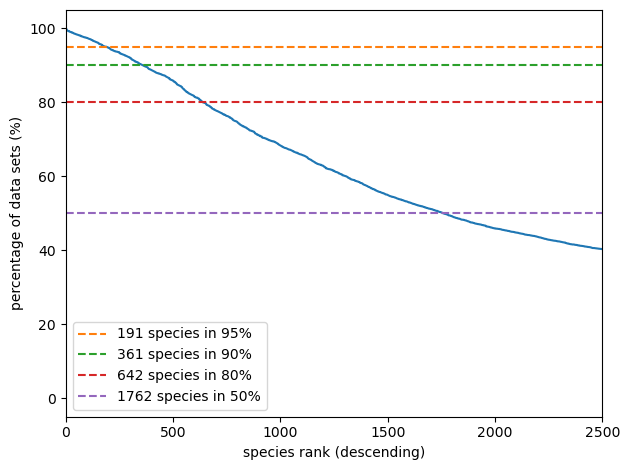

In [5]:
frac = 0
cutoff, total, group_df = filter_combined_df(all_df, frac)

len95 = len(group_df.filter(pl.col("frequency") >= 0.95))
len90 = len(group_df.filter(pl.col("frequency") >= 0.90))
len80 = len(group_df.filter(pl.col("frequency") >= 0.80))
len50 = len(group_df.filter(pl.col("frequency") >= 0.50))


plt.plot(group_df["rank"], group_df["frequency"]*100)
plt.plot([0, len(group_df)], [95, 95], '--', label=f'{len95} species in 95%')
plt.plot([0, len(group_df)], [90, 90], '--', label=f'{len90} species in 90%')
plt.plot([0, len(group_df)], [80, 80], '--', label=f'{len80} species in 80%')
plt.plot([0, len(group_df)], [50, 50], '--', label=f'{len50} species in 50%')

#plt.title("num core species at various thresholds in >= 1GB datasets")
plt.xlabel("species rank (descending)")
plt.ylabel("percentage of data sets (%)")
plt.legend(loc='lower left')
plt.xlim(0, 2500)
plt.tight_layout()

shape: (27_238, 5)
┌───────┬─────────────────────────────────┬──────┬────────────┬───────────┐
│ rank  ┆ species                         ┆ len  ┆ weight_med ┆ frequency │
│ ---   ┆ ---                             ┆ ---  ┆ ---        ┆ ---       │
│ u32   ┆ str                             ┆ u32  ┆ f64        ┆ f64       │
╞═══════╪═════════════════════════════════╪══════╪════════════╪═══════════╡
│ 0     ┆ s__Escherichia coli             ┆ 3216 ┆ 289500.0   ┆ 1.0       │
│ 1     ┆ s__Sodaliphilus sp004557565     ┆ 3214 ┆ 8.508e6    ┆ 0.999378  │
│ 2     ┆ s__Lactobacillus amylovorus     ┆ 3212 ┆ 2.9815e6   ┆ 0.998756  │
│ 3     ┆ s__UBA2868 sp004552595          ┆ 3210 ┆ 2.473e6    ┆ 0.998134  │
│ 4     ┆ s__Roseburia inulinivorans      ┆ 3200 ┆ 124500.0   ┆ 0.995025  │
│ 5     ┆ s__Prevotella sp000434975       ┆ 3199 ┆ 618000.0   ┆ 0.994714  │
│ 6     ┆ s__JAFBIX01 sp021531895         ┆ 3199 ┆ 657000.0   ┆ 0.994714  │
│ 7     ┆ s__Mogibacterium_A kristiansen… ┆ 3198 ┆ 1.572e6    ┆ 0.994

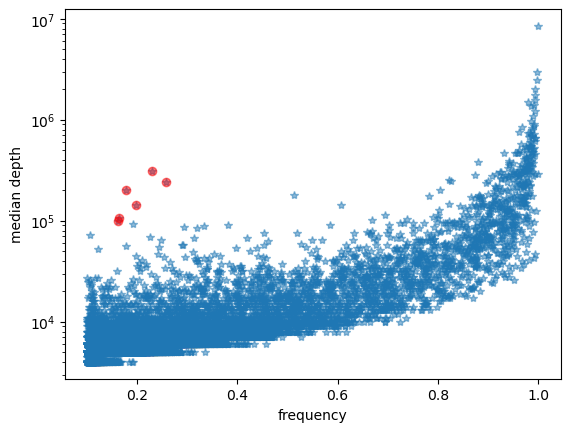

In [6]:
cutoff, total, group_df = filter_combined_df(all_df, 0.1)

with pl.Config(tbl_rows=50):
    print(group_df)

special_df = group_df.filter((pl.col("frequency") < 0.4) & (pl.col("weight_med") >= 1e5))

plt.plot(group_df['frequency'], group_df['weight_med'], '*', alpha=0.5)
plt.plot(special_df['frequency'], special_df['weight_med'], 'o', color="red", alpha=0.5)

plt.xlabel('frequency')
plt.ylabel('median depth')
plt.yscale('log')
#plt.xscale('log')

In [7]:
special_species = set(special_df['species'].unique().to_list())
special_species

{'s__Colicola sp946059305',
 's__Malacoplasma_A sp029009155',
 's__Prevotella sp022769285',
 's__Sodaliphilus sp934636465',
 's__Treponema_D sp945833725',
 's___RGIG3141 novel_116'}

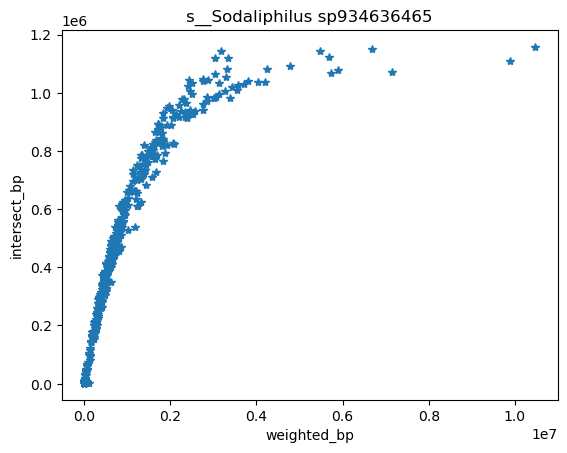

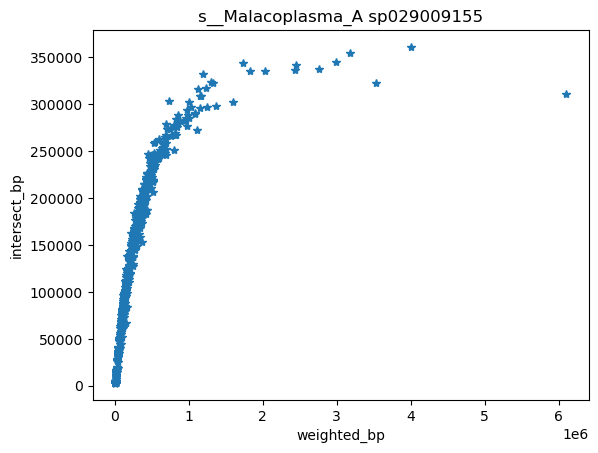

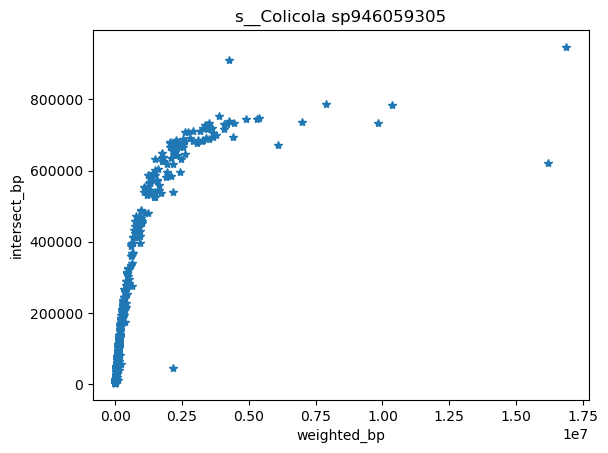

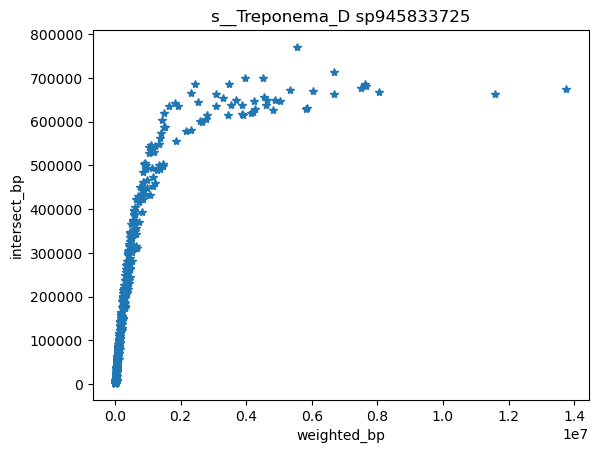

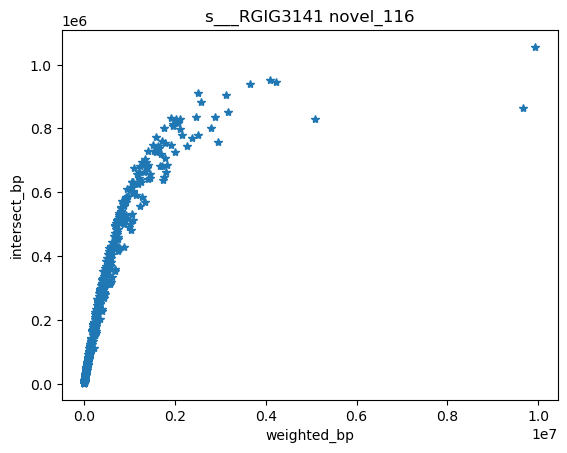

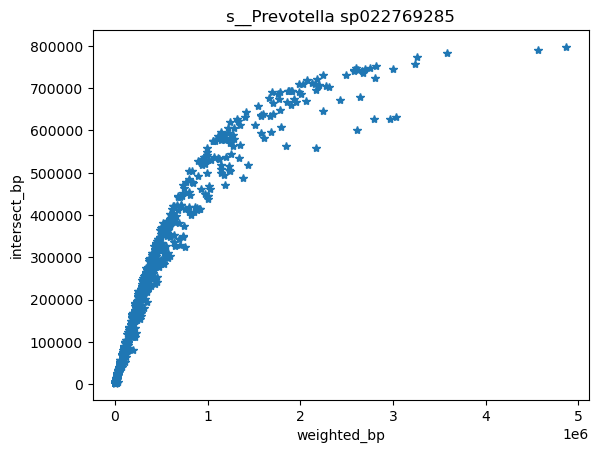

In [8]:
for SPECIES in special_species:
    species_df = all_df.filter(pl.col('species') == SPECIES)
    
    plt.plot(species_df['weighted_bp'], species_df['intersect_bp'], '*')
    plt.title(SPECIES)
    plt.xlabel('weighted_bp')
    plt.ylabel('intersect_bp')
    
    #plt.xlim(0, 1e8)
    plt.show()